In [1]:
import torch
import torch.nn as nn
from torch.autograd import Variable
import numpy as np
from torch.distributions import Normal, Independent, kl
import torchvision
import torchvision.transforms as T
from torch.distributions import Normal, Independent, kl, MultivariateNormal
from torch.utils.tensorboard import SummaryWriter
from torchmetrics import ConfusionMatrix
from ignite.metrics import *
from ProUNet import *
from torch.utils.data import DataLoader
from dataloader_cityscapes import *
import cv2
from frictionDataloader import *

In [2]:
kwargs = {}
kwargs["data_path"] = "../datasets/augmented_cityscapes"
kwargs["batch_size"] = 32
img_w = 256
img_h = 256

preprocess_in = transforms.Compose([
transforms.ToTensor(),
transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]),
transforms.Resize((256,256))
])

preprocess_ou = transforms.Compose([
transforms.ToTensor(),
transforms.Resize((256,256))
])


tr_loader = CityscapesLoader(dataset_path = kwargs["data_path"], transform_in = preprocess_in, transform_ou = preprocess_ou, mode = 'train')
train_loader = DataLoader(dataset = tr_loader, batch_size = kwargs["batch_size"], shuffle = True, drop_last = True)
kwargs["no_classes"] = tr_loader.get_num_classes()

val_loader = CityscapesLoader(dataset_path = kwargs["data_path"], transform_in = preprocess_in, transform_ou = preprocess_ou, mode = 'val')
val_loader = DataLoader(dataset = val_loader, batch_size = kwargs["batch_size"], shuffle = True, drop_last = True)

In [3]:
# input_img = torch.rand((1,3,256,256))
# seg_mask = torch.rand((1,3,256,256))
# seg_prob = torch.rand((1,34,256,256))
device = torch.device('cpu')
model = ProUNet(num_classes = 34, LatentVarSize = 6, beta = 5, training = True, num_samples = 16)
#optimizer = torch.optim.Adam(model.parameters(), lr =  0.00001, weight_decay = 0.00001)

/home/lunet/wsmo6/.conda/envs/3.6/lib/python3.6/site-packages/torch/nn/_reduction.py:42: UserWarning: size_average and reduce args will be deprecated, please use reduction='none' instead.
  warnings.warn(warning.format(ret))


In [4]:
check = torch.load("./checkpoints/cityscapes_HVAE1/best.pth", map_location=device)

In [5]:
model.load_state_dict(check['model_state_dict'])

<All keys matched successfully>

In [6]:
# seg, priorDists, posteriorDists = model(input_img,seg_mask)
# samples, priors, posteriorDists = model.evaluation(input_img,seg_prob)
# loss, kl_mean, kl_losses, rec_loss = model.elbo_loss(seg_test2, samples[0], priors, posteriorDists)

In [7]:
# loss.backward()
# optimizer.step()

In [8]:
dataset_arg = {
        "season": "Spring",
        "date": "16-05-2022",
        "hour": "16:34",
        "year": "2022"
}

preprocess_in = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]),
    transforms.Resize((256,256))
])


dataset = FrictionLoader(datasetConfig = dataset_arg, transform_in = preprocess_in)

In [9]:
# for batch in train_loader:

#     #forward pass
#     seg, priorDists, posteriorDists = model(batch['image'], batch['seg'])
#     #loss, kl_mean, kl_losses, rec_loss = model.elbo_loss(batch['label'], seg, priorDists, posteriorDists)
#     break

In [10]:
# sample = seg[10] / 255
# image = batch['image'][10] / 255

# ge_mask = tr_loader.prMask_to_color(sample.unsqueeze(0)).squeeze(0).permute(1, 2, 0) 

In [68]:
image = dataset[1200]["image"]
samples, _ = model.inference(image.unsqueeze(0))

In [69]:
sample = torch.mean(samples,0)
image = image

ge_mask = tr_loader.prMask_to_color(sample).squeeze(0).permute(1, 2, 0)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


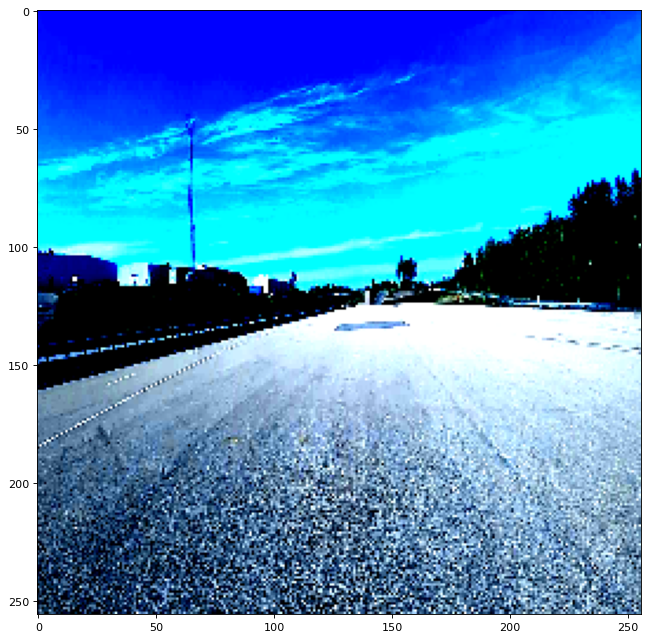

In [70]:
plt.figure(figsize=(12, 10), dpi=80)
plt.imshow(image.permute(1, 2, 0))
plt.show()

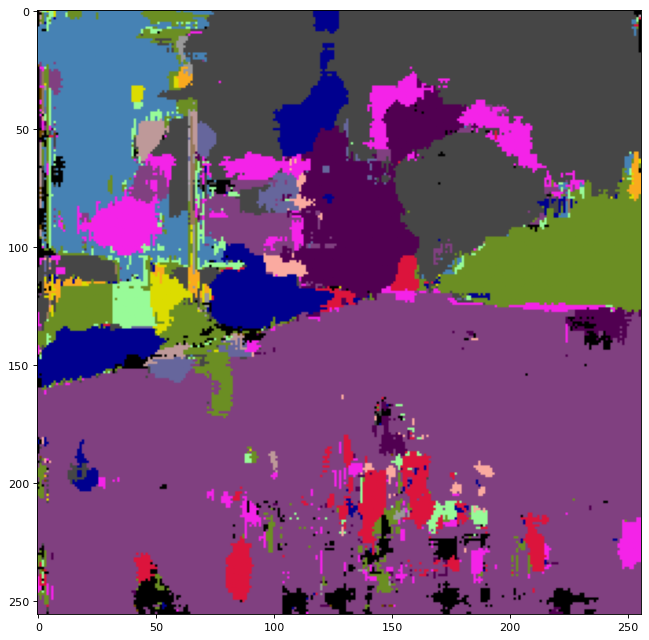

In [71]:
plt.figure(figsize=(12, 10), dpi=80)
plt.imshow(ge_mask/255)
plt.show()